In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [3]:
df = pd.read_csv('D:\\vs code projects\\swiggy_delivery_time\\data\\raw\\data.csv')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [4]:
# shape of data

rows, cols = df.shape

print("The dataset has {} rows and {} columns".format(rows,cols))

The dataset has 56992 rows and 20 columns


In [5]:
# datatypes of columns

(
    df.dtypes
    .rename("Data Types")
)

ID                                 str
Delivery_person_ID                 str
Delivery_person_Age                str
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                               str
Time_taken(min)                    str
Name: Data Types, dtype: object

In [6]:
# info about the data

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56992 entries, 0 to 56991
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           56992 non-null  str    
 1   Delivery_person_ID           56992 non-null  str    
 2   Delivery_person_Age          56992 non-null  str    
 3   Delivery_person_Ratings      56992 non-null  str    
 4   Restaurant_latitude          56992 non-null  float64
 5   Restaurant_longitude         56992 non-null  float64
 6   Delivery_location_latitude   56992 non-null  float64
 7   Delivery_location_longitude  56992 non-null  float64
 8   Order_Date                   56992 non-null  str    
 9   Time_Orderd                  56992 non-null  str    
 10  Time_Order_picked            56992 non-null  str    
 11  Weatherconditions            56992 non-null  str    
 12  Road_traffic_density         56992 non-null  str    
 13  Vehicle_condition          

Corrections:

Age column should be numerical.

Ratings should be float.

Date and time columns should be date and time.

Vehicle conditions seems to be categorical column which is integer encoded.

Multiple deliveries should be integer column.

Target column should also be numbers.

In [7]:
# missing values in data

df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [8]:
df.sample(50)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
47272,0x8f5f,MUMRES12DEL02,34,4.7,19.207222,72.972281,19.227222,72.992281,01-03-2022,11:10:00,11:20:00,conditions Windy,High,0,Snack,motorcycle,0,No,Metropolitian,(min) 32
651,0x5697,JAPRES13DEL02,20,4.8,26.846156,75.802300,26.896156,75.852300,26-03-2022,20:25:00,20:40:00,conditions Sandstorms,Jam,1,Drinks,scooter,0,No,Metropolitian,(min) 14
49181,0x585b,MYSRES18DEL02,38,4.5,12.337928,76.617889,12.417928,76.697889,02-03-2022,22:25:00,22:35:00,conditions Windy,Low,2,Meal,scooter,0,No,Metropolitian,(min) 14
51351,0x7e82,MYSRES04DEL01,35,4,12.308500,76.665808,12.318500,76.675808,30-03-2022,11:55:00,12:05:00,conditions Sandstorms,High,0,Meal,motorcycle,2,No,Metropolitian,(min) 21
14741,0x7fde,VADRES17DEL03,22,4.6,0.000000,0.000000,0.060000,0.060000,15-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,2,Snack,electric_scooter,0,No,Metropolitian,(min) 10
52885,0xccdb,LUDHRES05DEL01,32,3.5,30.905562,75.832841,31.015562,75.942841,18-02-2022,22:20:00,22:25:00,conditions Fog,Low,2,Drinks,scooter,1,No,Metropolitian,(min) 12
44969,0x978e,VADRES15DEL01,33,5,0.000000,0.000000,0.110000,0.110000,04-04-2022,18:15:00,18:30:00,conditions Fog,Medium,2,Drinks,scooter,2,No,Metropolitian,(min) 39
15868,0x3d49,MYSRES06DEL01,33,4.9,12.323994,76.626167,12.393994,76.696167,31-03-2022,18:30:00,18:35:00,conditions Cloudy,Medium,1,Meal,motorcycle,1,No,Metropolitian,(min) 30
30095,0x19b4,HYDRES12DEL02,36,4.8,17.429585,78.392621,17.479585,78.442621,05-03-2022,22:20:00,22:25:00,conditions Cloudy,Low,1,Buffet,scooter,1,No,Urban,(min) 15
53793,0x2835,SURRES20DEL02,21,2.6,21.152760,72.778059,21.282760,72.908059,29-03-2022,22:10:00,22:15:00,conditions Sunny,Low,2,Buffet,motorcycle,1,No,Metropolitian,(min) 19


In [9]:
df.loc[43317,'Delivery_person_Age']

'NaN '

In [10]:
df[df['Delivery_person_Age']=="NaN "]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
42,0x4f0,MUMRES17DEL02,NaN,NaN,19.121999,72.908493,19.201999,72.988493,06-04-2022,NaN,18:35:00,conditions Cloudy,Medium,1,Drinks,scooter,1,No,Metropolitian,(min) 33
74,0xa9f,BANGRES13DEL01,NaN,NaN,12.935662,77.614130,12.975662,77.654130,11-03-2022,NaN,15:30:00,conditions NaN,NaN,1,Drinks,scooter,0,No,Metropolitian,(min) 19
120,0x6e2,VADRES06DEL01,NaN,NaN,22.312790,73.170283,22.422790,73.280283,02-04-2022,NaN,18:25:00,conditions NaN,NaN,3,Snack,electric_scooter,0,No,Metropolitian,(min) 25
140,0x1ec7,PUNERES05DEL03,NaN,NaN,18.543626,73.905101,18.573626,73.935101,09-03-2022,NaN,23:40:00,conditions Stormy,Low,2,Snack,scooter,0,No,NaN,(min) 19
179,0x1b58,JAPRES03DEL01,NaN,NaN,26.913483,75.803139,26.983483,75.873139,12-03-2022,NaN,17:50:00,conditions Sandstorms,Medium,0,Drinks,motorcycle,0,No,Metropolitian,(min) 43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56861,0x1065,SURRES010DEL02,NaN,NaN,21.171060,72.789292,21.251060,72.869292,04-04-2022,NaN,23:30:00,conditions NaN,NaN,3,Meal,electric_scooter,1,No,NaN,(min) 44
56930,0x425,MUMRES15DEL02,NaN,NaN,-19.176269,-72.836721,19.306269,72.966721,10-03-2022,NaN,18:45:00,conditions NaN,NaN,3,Snack,bicycle,1,No,Metropolitian,(min) 24
56936,0x581,INDORES17DEL01,NaN,NaN,22.761226,75.887522,22.871226,75.997522,18-03-2022,NaN,21:55:00,conditions Sandstorms,Jam,1,Buffet,scooter,1,No,Urban,(min) 29
56985,0x116c,PUNERES04DEL03,NaN,NaN,18.514210,73.838429,18.544210,73.868429,07-03-2022,17:25:00,17:40:00,conditions Cloudy,Medium,0,Meal,motorcycle,0,No,Metropolitian,(min) 27


In [11]:
df['Weatherconditions'].value_counts()

Weatherconditions
conditions Fog           9422
conditions Stormy        9397
conditions Cloudy        9397
conditions Sandstorms    9373
conditions Windy         9370
conditions Sunny         9259
conditions NaN            774
Name: count, dtype: int64

In [12]:
df["Weatherconditions"]=df["Weatherconditions"].str.replace("conditions ","")

In [13]:
df['Weatherconditions'].value_counts()

Weatherconditions
Fog           9422
Stormy        9397
Cloudy        9397
Sandstorms    9373
Windy         9370
Sunny         9259
NaN            774
Name: count, dtype: int64

In [14]:
df["Weatherconditions"]=df["Weatherconditions"].replace("NaN",np.nan)

In [15]:
df['Weatherconditions'].value_counts()

Weatherconditions
Fog           9422
Stormy        9397
Cloudy        9397
Sandstorms    9373
Windy         9370
Sunny         9259
Name: count, dtype: int64

In [16]:
df['Weatherconditions'].isna().sum()

np.int64(774)

In [17]:
df=df.replace("NaN ",np.nan)

In [18]:
df.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            2345
Delivery_person_Ratings        2415
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    2175
Time_Order_picked                 0
Weatherconditions               774
Road_traffic_density            755
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries            1231
Festival                        293
City                           1524
Time_taken(min)                   0
dtype: int64

In [19]:
df.isna().sum().sum()

np.int64(11512)

<Axes: >

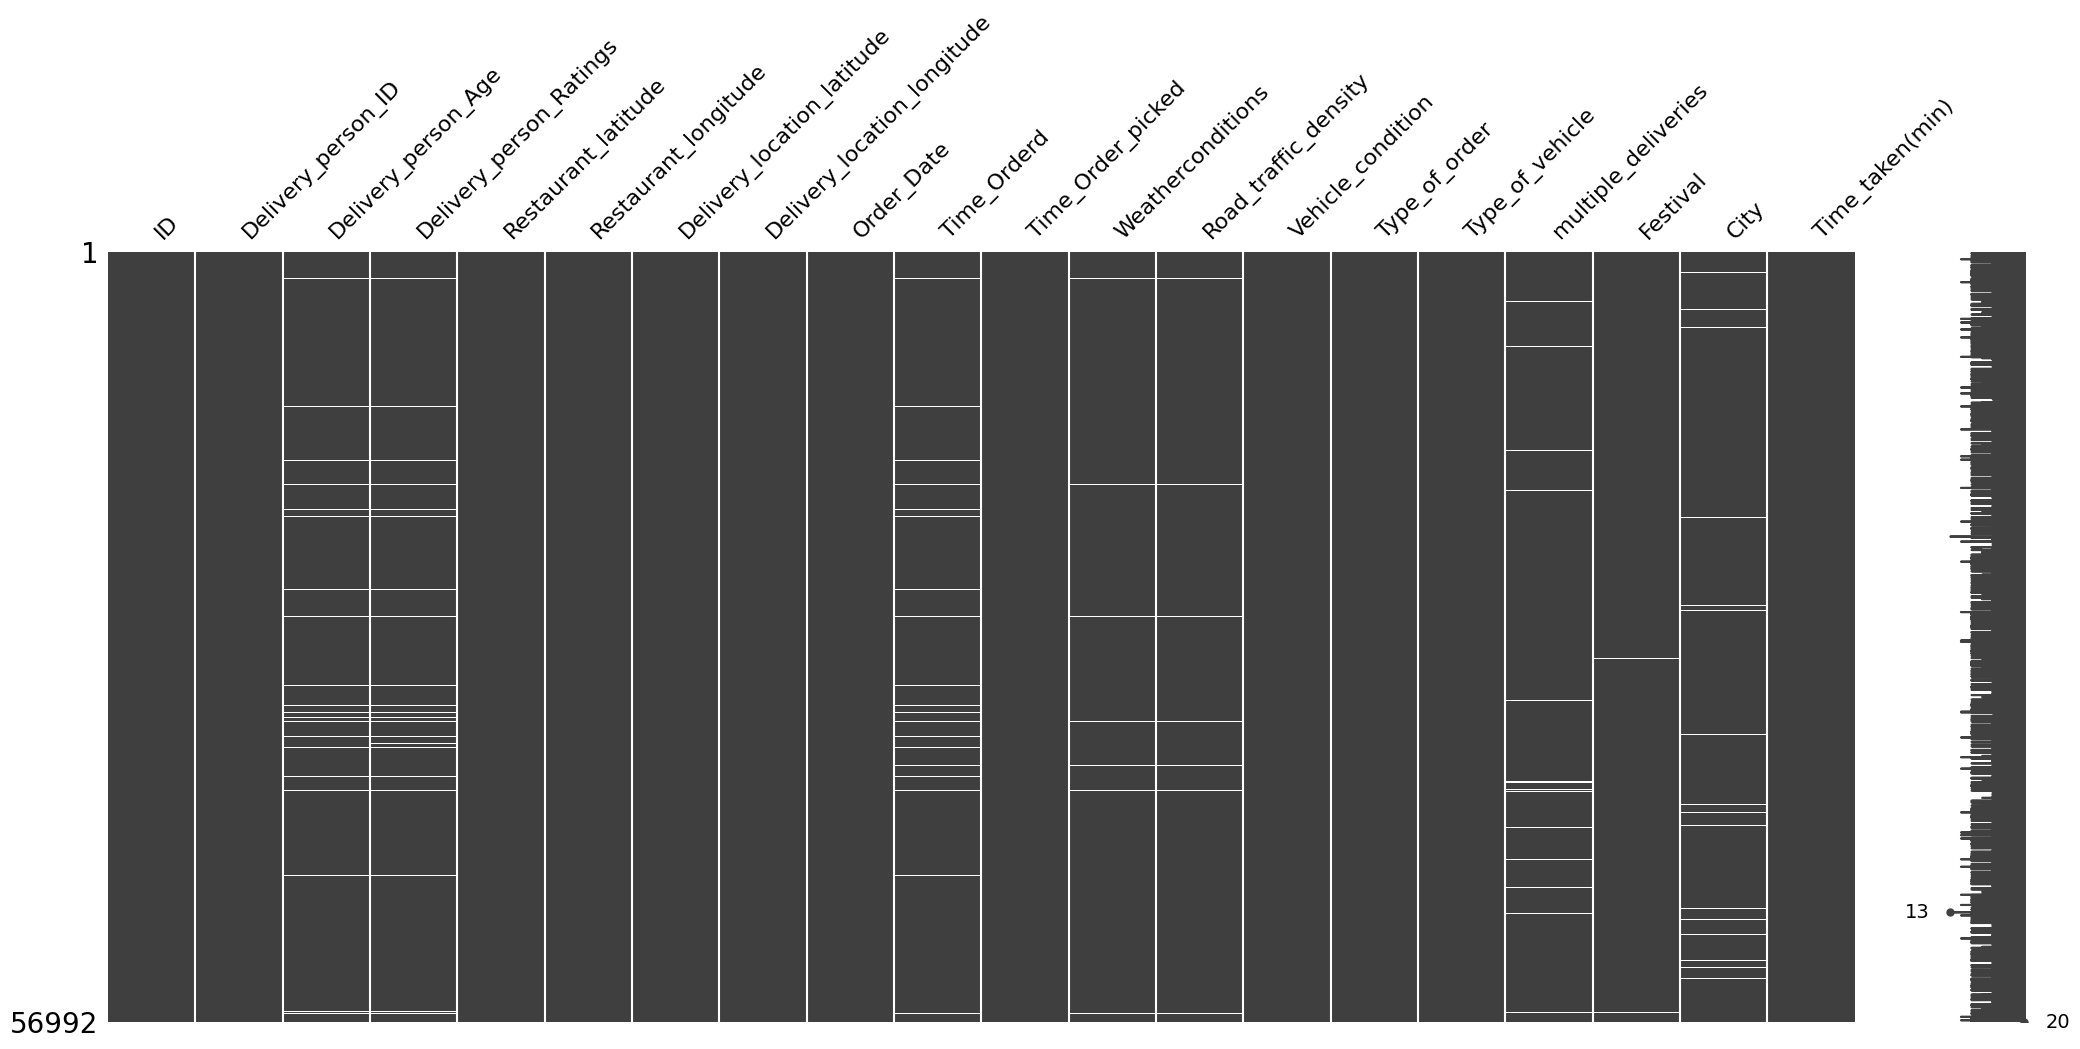

In [20]:
msno.matrix(df)

<Axes: >

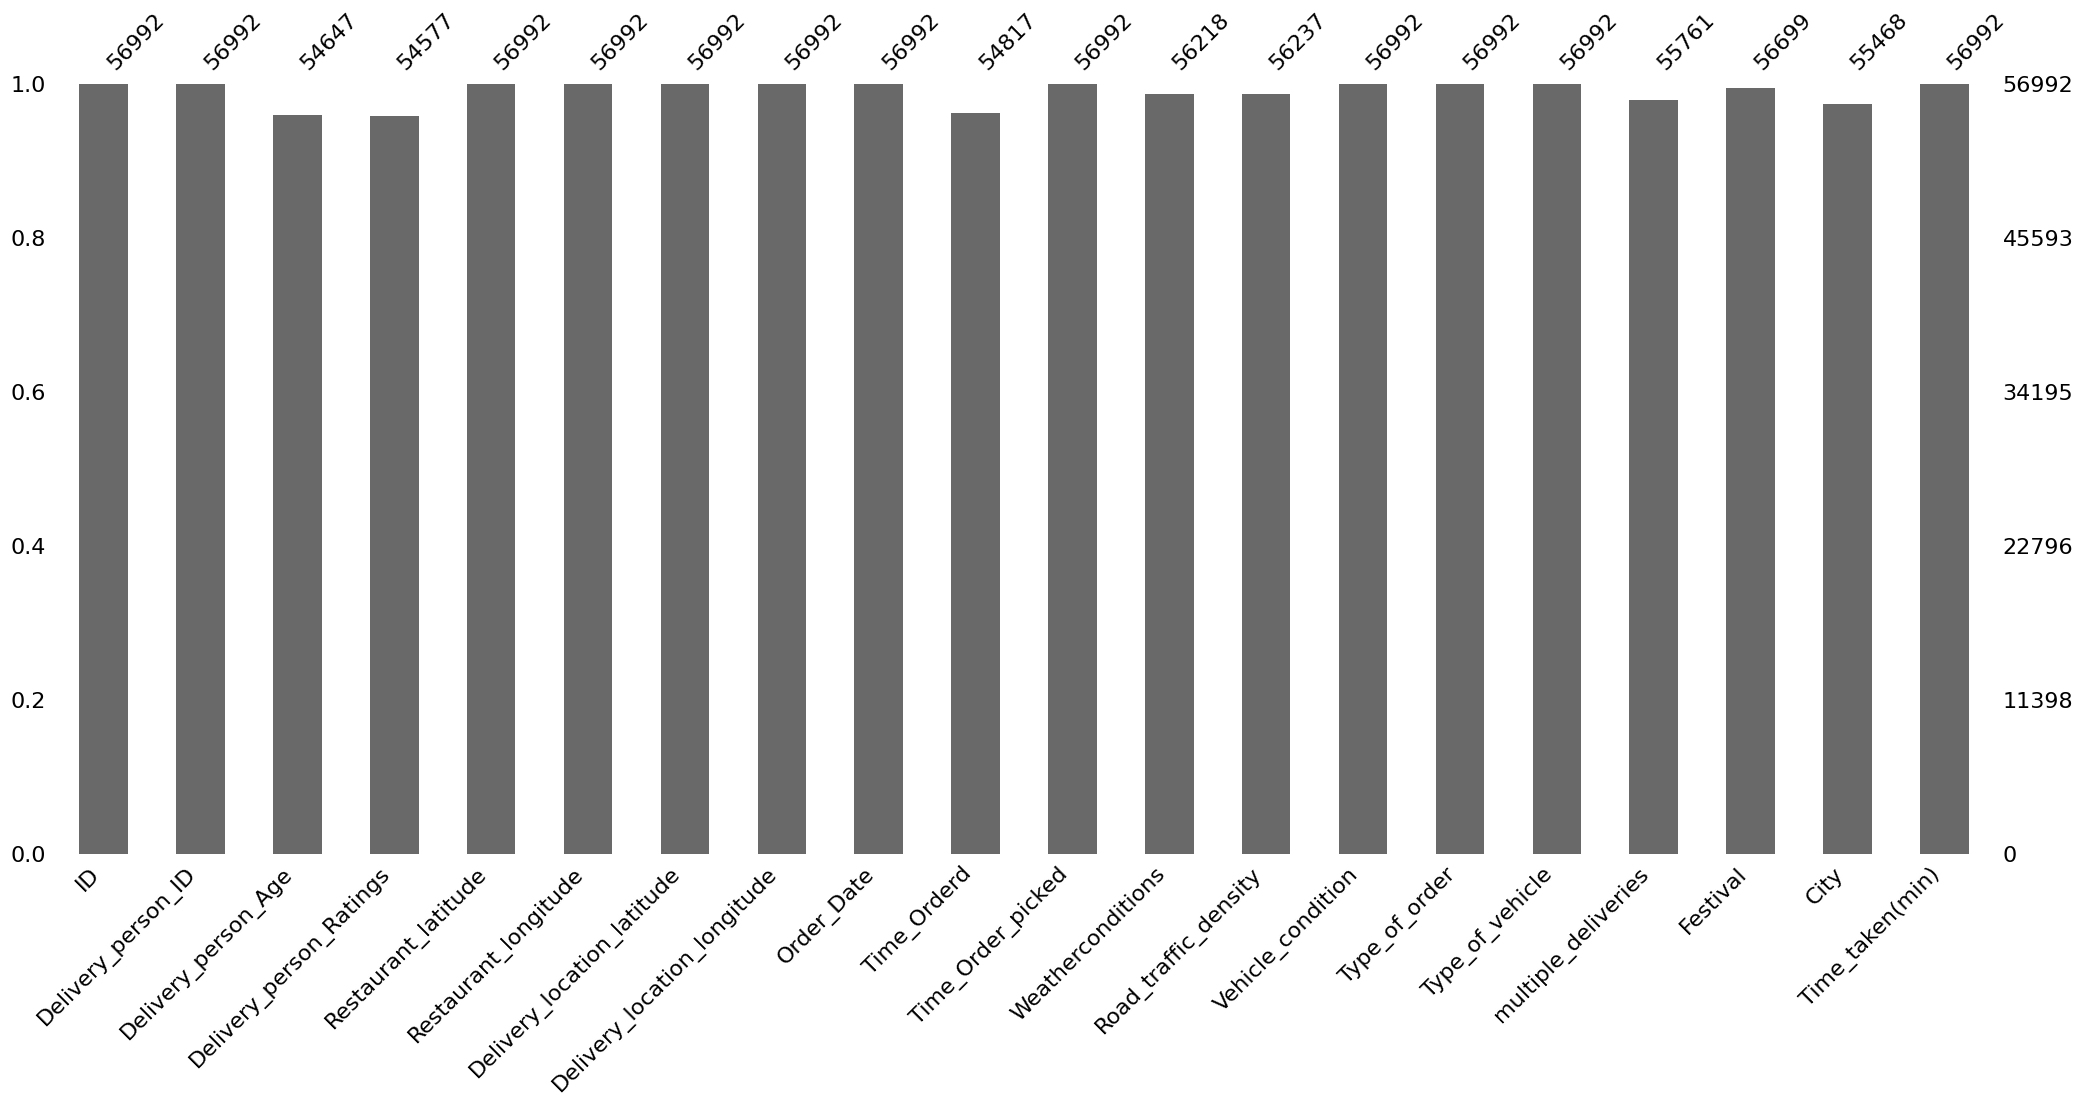

In [21]:
msno.bar(df)

<Axes: >

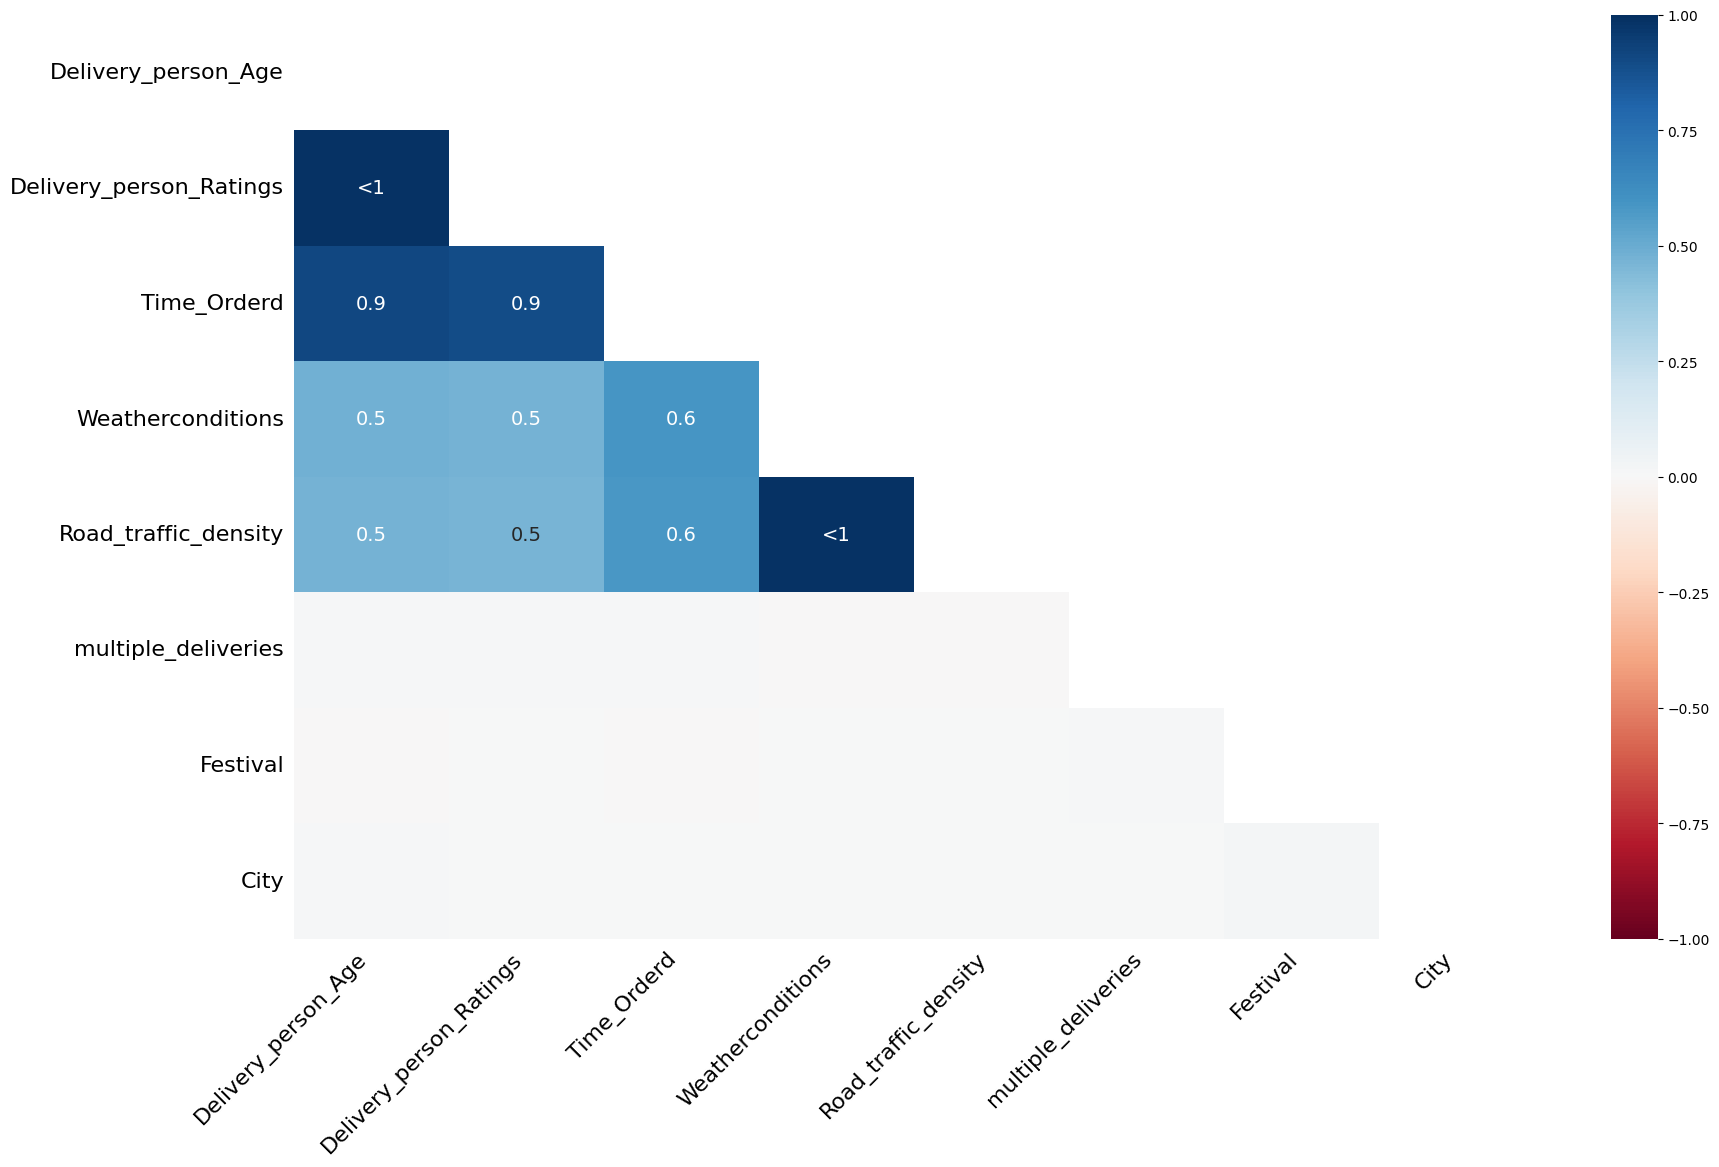

In [22]:
msno.heatmap(df)

Observations

The delivery person columns are correlated to each other. This means that missingness in these columns is highly related which means lack of rider data.

The time ordered column is also related to the rider which shows that the data might be missing due to some network error where the system was unable to log rider details and time of order.

There is a very high correlation between weather patterns and the road traffic information. Be clear that this does not mean that the road traffic and weather columns are correlated. High corr in missingness means that if value in one column is missing, it is a high chance that it will be missing in others as well.

Road traffic density also shows correlation to the rider as it might be provided through the phone of rider (need to investigate).

In [23]:
df[["Weatherconditions","Road_traffic_density"]].isna().all(axis=1).sum()

np.int64(755)

.all(axis=1) collapses each row to a single True only if both columns are missing in that row

In [24]:
df[["Weatherconditions","Road_traffic_density"]].isna().sum()

Weatherconditions       774
Road_traffic_density    755
dtype: int64

In [25]:
df[["Weatherconditions","Road_traffic_density"]].isna().all(axis=1).sum()/df[["Weatherconditions","Road_traffic_density"]].isna().sum()

Weatherconditions       0.975452
Road_traffic_density    1.000000
dtype: float64

<Axes: >

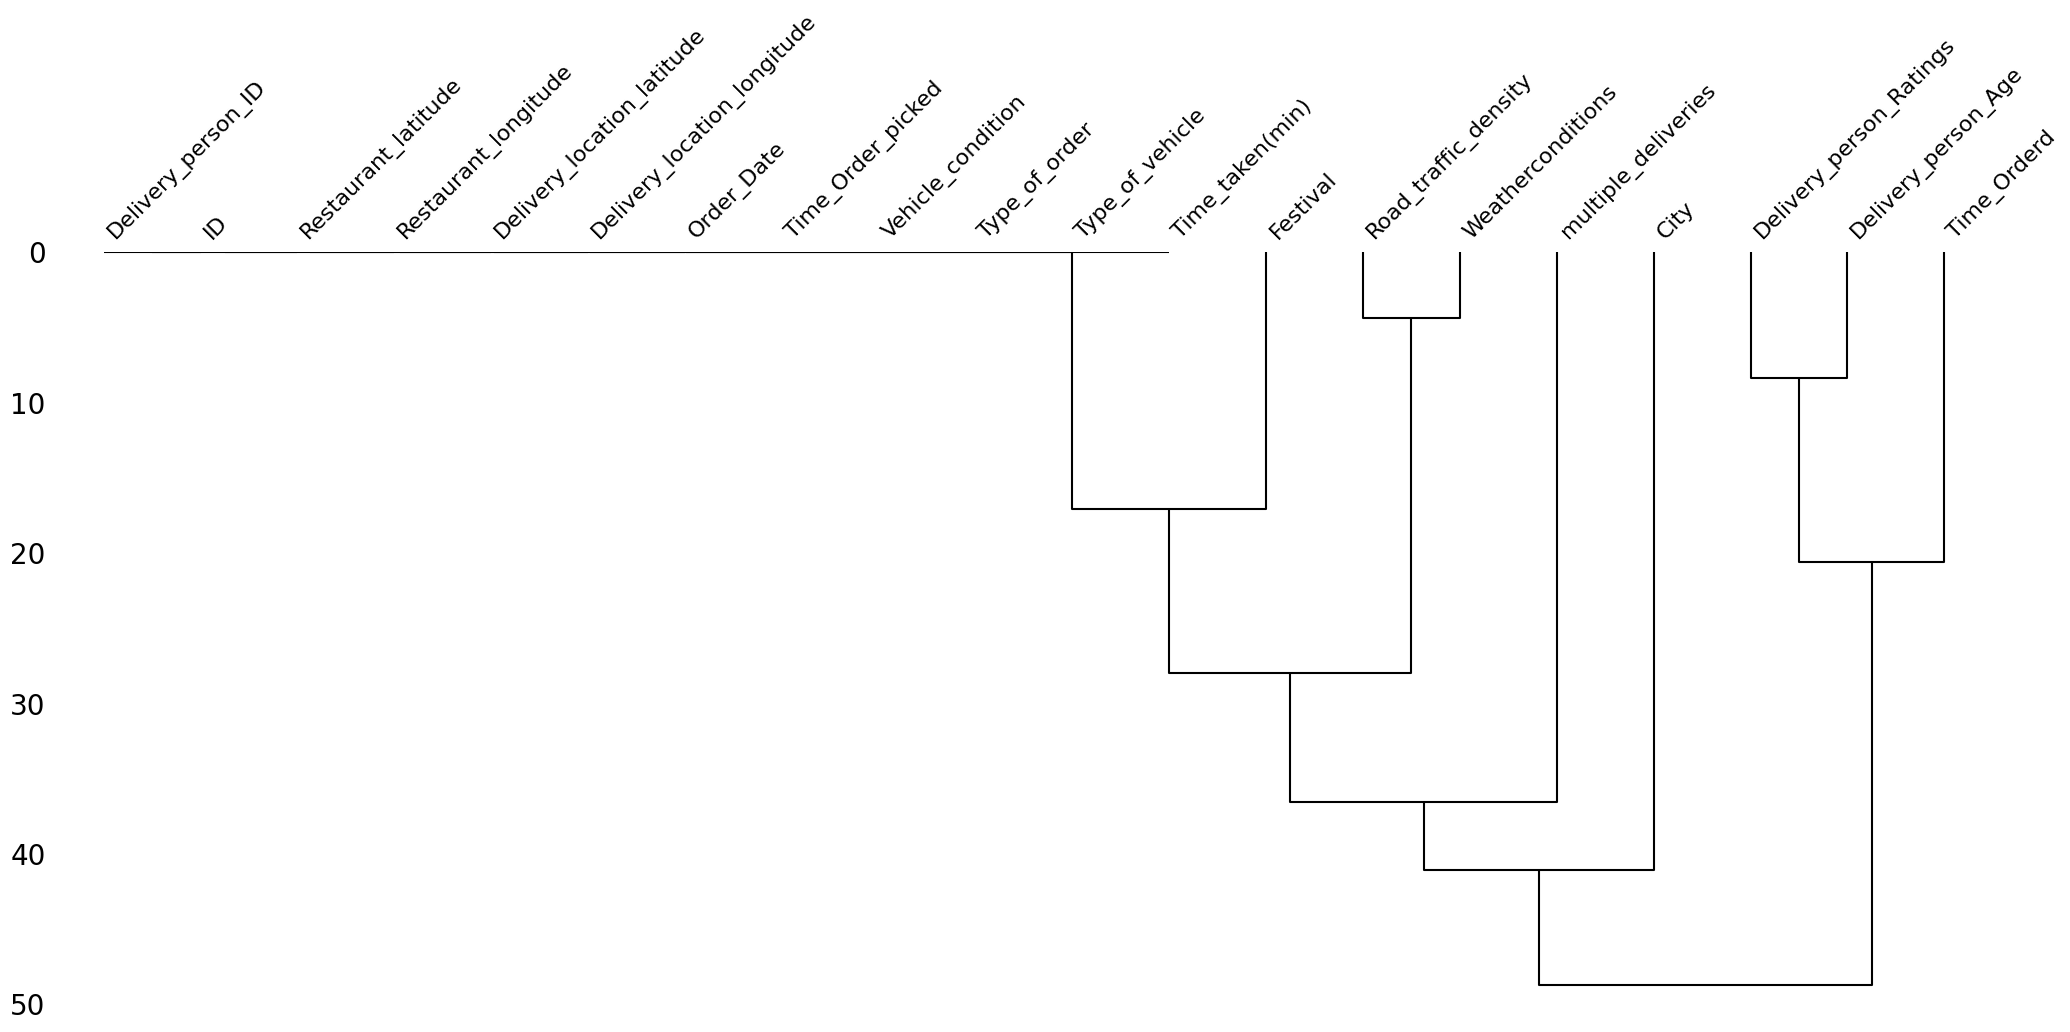

In [26]:
# dendrogram of missingness

msno.dendrogram(df)

In [27]:
# percentage of rows in the data having missing value

(df.isna().any(axis=1).sum() / df.shape[0]) * 100

np.float64(9.357453677709152)

In [28]:
def change_column_names(data: pd.DataFrame):
    return (
        data.rename(str.lower,axis=1)
        .rename({
            "delivery_person_id" : "rider_id",
            "delivery_person_age": "age",
            "delivery_person_ratings": "ratings",
            "delivery_location_latitude": "delivery_latitude",
            "delivery_location_longitude": "delivery_longitude",
            "time_orderd": "order_time",
            "time_order_picked": "order_picked_time",
            "weatherconditions": "weather",
            "road_traffic_density": "traffic",
            "city": "city_type",
            "time_taken(min)": "time_taken"},axis=1)
    )

In [29]:
df = change_column_names(df)

In [30]:
df.head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [31]:
df.drop(columns=["id","rider_id"]).duplicated().sum()

np.int64(0)

## column-wise cleaning

### Rider_id

In [32]:
df['rider_id'].nunique()

1320

The data contains 1320 unique riders

In [33]:
df['rider_id'].value_counts()

rider_id
INDORES13DEL02      72
BANGRES18DEL02      72
BANGRES19DEL01      72
COIMBRES13DEL02     72
CHENRES12DEL01      72
                    ..
BHPRES08DEL03       12
GOARES01DEL03       12
KOCRES08DEL03       12
BHPRES06DEL03       12
GOARES03DEL03       12
Name: count, Length: 1320, dtype: int64

In [34]:
# extract city name out of rider id

(
    df['rider_id']
    .str.split("RES")
    .str.get(0)
    .rename("City_Name")
)

0         INDO
1         BANG
2         BANG
3        COIMB
4         CHEN
         ...  
56987      JAP
56988      JAP
56989      SUR
56990      VAD
56991     CHEN
Name: City_Name, Length: 56992, dtype: object

In [35]:
df.head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


### Age

In [36]:
# datatype

df['age'].dtype

<StringDtype(na_value=nan)>

In [37]:
df['age'].astype(float).describe()

count    54647.000000
mean        29.557176
std          5.811533
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: age, dtype: float64

Minimum Rider age of 15 is concerning

Investigate further what type of transport is he using?

<Axes: ylabel='age'>

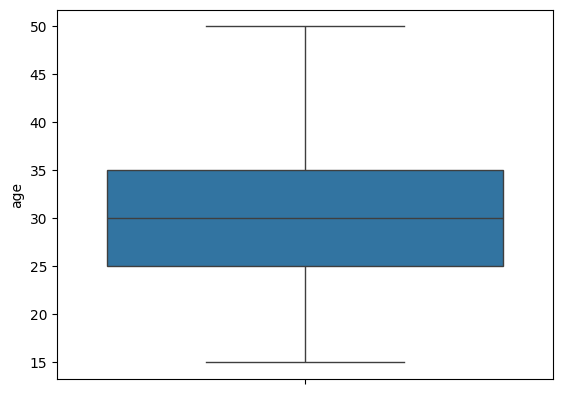

In [38]:
sns.boxplot(df['age'].astype(float))

In [39]:
# rows of data where rider age is less than 18(minor)


minors_data = df[df['age'].astype('float') < 18]

minors_data

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
2387,0x564,JAPRES15DEL03,15,1,-26.891191,75.802083,26.981191,75.892083,12-03-2022,NaN,17:20:00,NaN,NaN,3,Meal,motorcycle,0,No,Urban,(min) 15
2905,0xcd0,INDORES010DEL03,15,1,22.750040,75.902847,22.810040,75.962847,03-04-2022,NaN,20:30:00,NaN,NaN,3,Snack,scooter,1,No,Metropolitian,(min) 29
2951,0x91a,SURRES17DEL03,15,1,21.149569,72.772697,21.209569,72.832697,21-03-2022,NaN,22:10:00,NaN,NaN,3,Buffet,bicycle,1,No,Metropolitian,(min) 20
5902,0x474,CHENRES15DEL03,15,1,13.026286,80.275235,13.056286,80.305235,11-03-2022,NaN,20:50:00,NaN,NaN,3,Drinks,bicycle,1,No,Metropolitian,(min) 25
9156,0x73f,BANGRES05DEL01,15,1,12.970324,77.645748,13.080324,77.755748,25-03-2022,NaN,23:25:00,NaN,NaN,3,Buffet,motorcycle,2,No,Metropolitian,(min) 34
10900,0x1b49,MUMRES14DEL02,15,1,19.181300,72.836191,19.231300,72.886191,30-03-2022,NaN,20:55:00,NaN,NaN,3,Buffet,motorcycle,1,No,Metropolitian,(min) 39
11125,0x40b,SURRES12DEL01,15,1,-21.183434,-72.814492,21.193434,72.824492,05-03-2022,NaN,11:30:00,NaN,NaN,3,Meal,scooter,1,No,Urban,(min) 27
12093,0x523,INDORES03DEL02,15,1,22.751857,75.866699,22.801857,75.916699,24-03-2022,NaN,21:15:00,NaN,NaN,3,Buffet,bicycle,0,No,Metropolitian,(min) 28
15124,0x18b0,RANCHIRES02DEL01,15,1,0.000000,0.000000,0.070000,0.070000,16-03-2022,NaN,23:55:00,NaN,NaN,3,Meal,bicycle,1,No,Metropolitian,(min) 21
15927,0x550,CHENRES08DEL02,15,1,13.022394,80.242439,13.072394,80.292439,11-03-2022,NaN,18:10:00,NaN,NaN,3,Snack,bicycle,0,No,Metropolitian,(min) 17


Observations:

The star ratings of all the riders is 1.

The vehicle condition of these riders is very bad.

No weather and traffic conditions available.

Age of all these riders is 15 which is below the permissable age to drive a vehicle.

Latitude and Longitude values in negative which is not possible. India is situated above the equator so all latitudes should be positive and east of meridian line so longitudes are positive as well.

### Ratings

In [40]:
df['ratings'].dtype

<StringDtype(na_value=nan)>

In [41]:
df['ratings'].astype(float).describe()

count    54577.000000
mean         4.633582
std          0.336603
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: ratings, dtype: float64

6 Star rating is possibly a data error

<Axes: ylabel='ratings'>

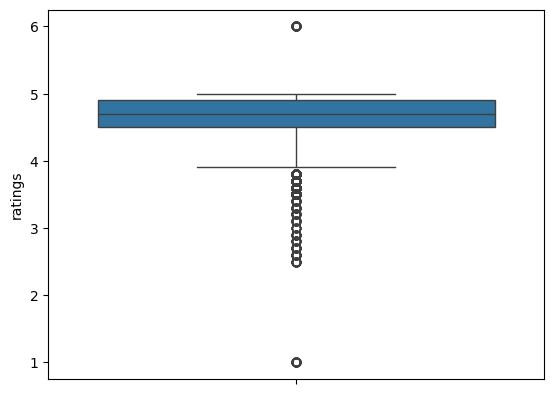

In [42]:
sns.boxplot(df['ratings'].astype(float))

1. The Minors data have ratings as 1 which seems like an anomaly if we generally consider the ratings column distribution.

2. The rating of 6 is also one another anomaly in the data as maximum ratings are 5 and not more than that

a. Has to be investigated

b. If data is problematic than fixing or removing is an option

In [43]:
six_star_data = df.loc[df['ratings'] == "6"]

len(six_star_data)

63

### Location Columns

In [44]:
location_columns = df.columns[4:8].tolist()

location_columns

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

In [45]:
location_subset = df.loc[:,location_columns]
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
0,22.745049,75.892471,22.765049,75.912471
1,12.913041,77.683237,13.043041,77.813237
2,12.914264,77.678400,12.924264,77.688400
3,11.003669,76.976494,11.053669,77.026494
4,12.972793,80.249982,13.012793,80.289982
...,...,...,...,...
56987,26.905190,75.810753,27.015190,75.920753
56988,26.902940,75.793007,26.912940,75.803007
56989,21.157735,72.768778,21.217735,72.828778
56990,22.320000,73.170000,22.450000,73.300000


Valid values for lat and long

India lies to the north of the equator between 6° 44′ and 35° 30′ north latitude and 68° 7′ and 97° 25′ east longitude

In [46]:
location_subset.describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,56992.000000,56992.000000,56992.000000,56992.000000
mean,17.034171,70.264920,17.486049,70.897002
std,8.186784,22.861487,7.325665,21.034559
min,-30.905562,-88.400467,0.010000,0.010000
25%,12.933284,73.170283,12.989166,73.293329
50%,18.551440,75.897429,18.636258,76.002471
75%,22.728163,78.045359,22.785536,78.107053
max,30.914057,88.433452,31.054057,88.563452


In [47]:
lower_bound_lat = 6.44
lower_bound_long = 68.70

In [48]:
upper_bound_lat=35.30
upper_bound_long=97.25

In [49]:
df.loc[
    (df['restaurant_latitude'] < lower_bound_lat) | (df['restaurant_latitude'] > upper_bound_lat) |
    (df['restaurant_longitude'] < lower_bound_long) | (df['restaurant_longitude'] > upper_bound_long) |
    (df['delivery_latitude'] < lower_bound_lat) | (df['delivery_latitude'] > upper_bound_lat) |
    (df['delivery_longitude'] < lower_bound_long) | (df['delivery_longitude'] > upper_bound_long)
].sample(50)

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
34122,0x6de0,RANCHIRES03DEL03,38,4.1,0.000000,0.000000,0.060000,0.060000,21-03-2022,19:40:00,19:45:00,Windy,Jam,1,Meal,motorcycle,1,No,Urban,(min) 31
5258,0x8786,VADRES16DEL02,39,4.7,0.000000,0.000000,0.130000,0.130000,20-03-2022,23:15:00,23:30:00,Stormy,Low,0,Drinks,motorcycle,1,No,Metropolitian,(min) 28
5967,0xcf1a,AGRRES15DEL02,39,4.8,0.000000,0.000000,0.130000,0.130000,16-02-2022,18:50:00,19:00:00,Cloudy,Medium,0,Meal,motorcycle,1,Yes,Metropolitian,(min) 41
43228,0x9e62,VADRES07DEL02,32,4.9,0.000000,0.000000,0.050000,0.050000,13-03-2022,22:40:00,22:55:00,Stormy,Low,1,Buffet,scooter,0,No,Urban,(min) 23
30473,0x553,VADRES12DEL01,NaN,NaN,0.000000,0.000000,0.070000,0.070000,18-03-2022,NaN,20:45:00,NaN,NaN,3,Buffet,scooter,1,No,Metropolitian,(min) 43
22222,0xc637,KNPRES06DEL03,30,4.1,0.000000,0.000000,0.090000,0.090000,18-02-2022,19:20:00,19:25:00,Windy,Jam,2,Buffet,scooter,1,No,Metropolitian,(min) 31
19777,0x43dd,RANCHIRES03DEL01,28,4.9,0.000000,0.000000,0.040000,0.040000,26-03-2022,14:00:00,14:05:00,Windy,High,2,Drinks,scooter,0,No,Metropolitian,(min) 22
10228,0xc060,KNPRES07DEL02,30,4.6,-26.472001,80.354002,26.552001,80.434002,18-02-2022,20:25:00,20:35:00,Stormy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 42
2775,0x7cc,VADRES04DEL02,22,4,0.000000,0.000000,0.050000,0.050000,15-03-2022,23:50:00,00:05:00,Stormy,Low,0,Buffet,motorcycle,1,No,Metropolitian,(min) 15
49156,0xd6f1,AURGRES11DEL02,21,5,0.000000,0.000000,0.020000,0.020000,17-02-2022,10:50:00,10:55:00,Sunny,Low,2,Buffet,scooter,1,No,Urban,(min) 19


In [50]:
location_subset.loc[
    (location_subset['restaurant_latitude'] < lower_bound_lat) | (location_subset['restaurant_latitude'] > upper_bound_lat) |
    (location_subset['restaurant_longitude'] < lower_bound_long) | (location_subset['restaurant_longitude'] > upper_bound_long) |
    (location_subset['delivery_latitude'] < lower_bound_lat) | (location_subset['delivery_latitude'] > upper_bound_lat) |
    (location_subset['delivery_longitude'] < lower_bound_long) | (location_subset['delivery_longitude'] > upper_bound_long)
].shape[0]

5055

In [51]:
# statistical summary of problematic rows where lat long is below the country's geographical limits

location_subset.loc[
    (location_subset['restaurant_latitude'] < lower_bound_lat) | (location_subset['restaurant_latitude'] > upper_bound_lat) |
    (location_subset['restaurant_longitude'] < lower_bound_long) | (location_subset['restaurant_longitude'] > upper_bound_long) |
    (location_subset['delivery_latitude'] < lower_bound_lat) | (location_subset['delivery_latitude'] > upper_bound_lat) |
    (location_subset['delivery_longitude'] < lower_bound_long) | (location_subset['delivery_longitude'] > upper_bound_long)
].describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,5055.000000,5055.000000,5055.000000,5055.000000
mean,-2.188584,1.971300,2.251407,8.442977
std,6.590931,25.484569,6.591316,24.147944
min,-30.905562,-88.400467,0.010000,0.010000
25%,0.000000,0.000000,0.040000,0.040000
50%,0.000000,0.000000,0.070000,0.070000
75%,0.000000,0.000000,0.110000,0.110000
max,0.000000,88.433452,31.045562,88.563452


(array([1, 2, 3, 4]),
 [Text(1, 0, 'restaurant_latitude'),
  Text(2, 0, 'restaurant_longitude'),
  Text(3, 0, 'delivery_latitude'),
  Text(4, 0, 'delivery_longitude')])

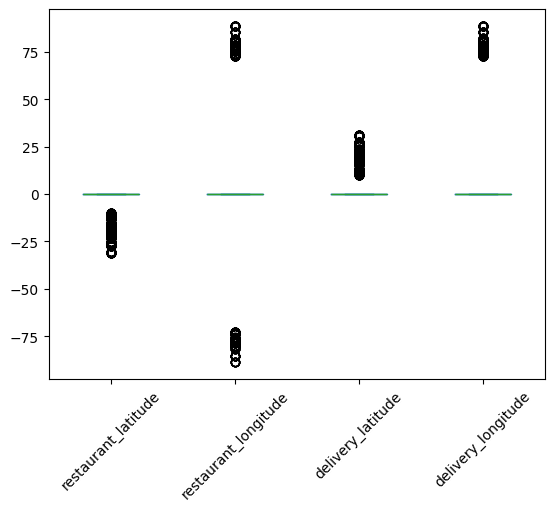

In [52]:
# boxplots for all the anomalies

location_subset.loc[
    (location_subset['restaurant_latitude'] < lower_bound_lat) | (location_subset['restaurant_latitude'] > upper_bound_lat) |
    (location_subset['restaurant_longitude'] < lower_bound_long) | (location_subset['restaurant_longitude'] > upper_bound_long) |
    (location_subset['delivery_latitude'] < lower_bound_lat) | (location_subset['delivery_latitude'] > upper_bound_lat) |
    (location_subset['delivery_longitude'] < lower_bound_long) | (location_subset['delivery_longitude'] > upper_bound_long)
].plot(kind="box")

plt.xticks(rotation=45)


Negative Values are correct just we have to take absolute

While calculating the distances we can assign null values to these erroneous data points and then impute the values using advanced imputation techniques

[Text(1, 0, 'restaurant_latitude'),
 Text(2, 0, 'restaurant_longitude'),
 Text(3, 0, 'delivery_latitude'),
 Text(4, 0, 'delivery_longitude')]

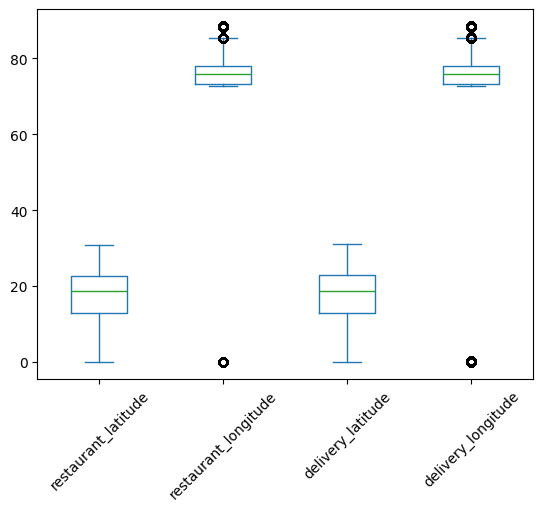

In [53]:
# taking the absolute values

(
    location_subset.abs()
    .plot(kind="box")
)

ax = plt.gca()

ax.set_xticklabels(ax.get_xticklabels(),rotation=45)

In [54]:
# number of rows after taking absolute values

(
    location_subset.abs()
    .loc[lambda df_:
    (df_['restaurant_latitude'] < lower_bound_lat) | (df_['restaurant_latitude'] > upper_bound_lat) |
    (df_['restaurant_longitude'] < lower_bound_long) | (df_['restaurant_longitude'] > upper_bound_long) |
    (df_['delivery_latitude'] < lower_bound_lat) | (df_['delivery_latitude'] > upper_bound_lat) |
    (df_['delivery_longitude'] < lower_bound_long) | (df_['delivery_latitude'] > upper_bound_long)]
.shape[0]

)

4510

4510 rows in the data that have messy lat long values

In [55]:
# lat long values less than 1

location_subset.abs().loc[lambda df_:
                        (df_['restaurant_latitude'] < 1) |
                        (df_['restaurant_longitude'] < 1) |
                        (df_['delivery_latitude'] < 1) |
                        (df_['delivery_longitude'] < 1)]

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
33,0.0,0.0,0.11,0.11
52,0.0,0.0,0.03,0.03
57,0.0,0.0,0.08,0.08
59,0.0,0.0,0.06,0.06
67,0.0,0.0,0.02,0.02
...,...,...,...,...
56949,0.0,0.0,0.11,0.11
56960,0.0,0.0,0.06,0.06
56976,0.0,0.0,0.02,0.02
56984,0.0,0.0,0.06,0.06


In [56]:
def clean_lat_long(data: pd.DataFrame, threshold=1):
    location_columns = location_subset.columns.tolist()

    return (
        data
        .assign(**{
            col: (
                np.where(data[col].abs() < threshold, np.nan, data[col].values)
            )
            for col in location_columns
        })
    )

In [57]:
clean_lat_long(df).isna().sum()

id                         0
rider_id                   0
age                     2345
ratings                 2415
restaurant_latitude     4510
restaurant_longitude    4510
delivery_latitude       4510
delivery_longitude      4510
order_date                 0
order_time              2175
order_picked_time          0
weather                  774
traffic                  755
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries     1231
festival                 293
city_type               1524
time_taken                 0
dtype: int64

### Order Date

In [58]:
# check for missing values

df['order_date'].isna().sum()

np.int64(0)

In [59]:
df['order_date'].unique()

<ArrowStringArray>
['19-03-2022', '25-03-2022', '05-04-2022', '26-03-2022', '11-03-2022',
 '04-03-2022', '14-03-2022', '20-03-2022', '12-02-2022', '13-02-2022',
 '14-02-2022', '02-04-2022', '01-03-2022', '16-03-2022', '15-02-2022',
 '10-03-2022', '27-03-2022', '12-03-2022', '01-04-2022', '05-03-2022',
 '11-02-2022', '08-03-2022', '03-04-2022', '30-03-2022', '28-03-2022',
 '18-03-2022', '06-04-2022', '04-04-2022', '24-03-2022', '09-03-2022',
 '02-03-2022', '13-03-2022', '29-03-2022', '31-03-2022', '17-03-2022',
 '07-03-2022', '15-03-2022', '16-02-2022', '03-03-2022', '18-02-2022',
 '23-03-2022', '17-02-2022', '06-03-2022', '21-03-2022']
Length: 44, dtype: str

In [60]:
order_date = pd.to_datetime(df['order_date'],dayfirst=True)

order_date.max() - order_date.min()

Timedelta('54 days 00:00:00')

In [61]:
order_date.agg(["min","max"]).set_axis(["start","end"],axis=0)

start   2022-02-11
end     2022-04-06
Name: order_date, dtype: datetime64[us]

In [62]:
# extract day, day name, month and year

def extract_datetime_features(ser):
    date_col = pd.to_datetime(ser,dayfirst=True)

    return (
        pd.DataFrame(
            {
                "day": date_col.dt.day,
                "month": date_col.dt.month,
                "year": date_col.dt.year,
                "day_of_week": date_col.dt.day_name(),
                "is_weekend": date_col.dt.day_name().isin(["Saturday","Sunday"]).astype(int)
            }
        ))

In [63]:
extract_datetime_features(df['order_date'])

,day,month,year,day_of_week,is_weekend
0,19,3,2022,Saturday,1
1,25,3,2022,Friday,0
2,19,3,2022,Saturday,1
3,5,4,2022,Tuesday,0
4,26,3,2022,Saturday,1
...,...,...,...,...,...
56987,27,3,2022,Sunday,1
56988,11,3,2022,Friday,0
56989,11,3,2022,Friday,0
56990,6,3,2022,Sunday,1


### Order time and Order picked time

In [64]:
# extract hour info from data

order_time_hr = pd.to_datetime(df.replace("NaN ",np.nan)['order_time'],format='mixed').dt.hour

order_time_hr

0        11.0
1        19.0
2         8.0
3        18.0
4        13.0
         ... 
56987    21.0
56988    11.0
56989     NaN
56990    18.0
56991    22.0
Name: order_time, Length: 56992, dtype: float64

In [65]:
def time_of_day(ser):
    time_col = pd.to_datetime(ser,format='mixed').dt.hour

    return(
        np.select(condlist=[(ser.between(6,12,inclusive='left')),
                            (ser.between(12,17,inclusive='left')),
                            (ser.between(17,20,inclusive='left')),
                            (ser.between(20,24,inclusive='left'))],
                  choicelist=["morning","afternoon","evening","night"],
                  default="after_midnight")
    )

In [66]:
time_subset = df.loc[:,["order_time","order_picked_time"]]
time_subset

,order_time,order_picked_time
0,11:30:00,11:45:00
1,19:45:00,19:50:00
2,08:30:00,08:45:00
3,18:00:00,18:10:00
4,13:30:00,13:45:00
...,...,...
56987,21:35:00,21:45:00
56988,11:40:00,11:45:00
56989,NaN,21:05:00
56990,18:35:00,18:40:00


In [67]:
# calculate the pickup time

(
    time_subset
    .assign(**{
        col: pd.to_datetime(time_subset[col].replace("NaN ",np.nan).dropna(),format="mixed")
        for col in time_subset.columns.tolist()}
    )
    .assign(
        pickup_time = lambda x: (x['order_picked_time'] - x['order_time']).dt.seconds / 60,
        order_time_hour = lambda x: x['order_time'].dt.hour,
        order_time_of_day = lambda x: x['order_time_hour'].pipe(time_of_day)
    )
    .drop(columns=["order_time","order_picked_time"])
)

,pickup_time,order_time_hour,order_time_of_day
0,15.0,11.0,morning
1,5.0,19.0,evening
2,15.0,8.0,morning
3,10.0,18.0,evening
4,15.0,13.0,afternoon
...,...,...,...
56987,10.0,21.0,night
56988,5.0,11.0,morning
56989,NaN,NaN,after_midnight
56990,5.0,18.0,evening


### Weather

In [68]:
df['weather'].value_counts()

weather
Fog           9422
Stormy        9397
Cloudy        9397
Sandstorms    9373
Windy         9370
Sunny         9259
Name: count, dtype: int64

In [69]:
df['weather'].isna().sum()

np.int64(774)

### Traffic

In [70]:
df['traffic'].value_counts()

traffic
Low        19358
Jam        17646
Medium     13698
High        5535
Name: count, dtype: int64

In [71]:
df['traffic'].isna().sum()

np.int64(755)

### Vehicle Condition

In [72]:
df['vehicle_condition'].value_counts()

vehicle_condition
2    18855
1    18764
0    18726
3      647
Name: count, dtype: int64

In [73]:
df['vehicle_condition'].isna().sum()

np.int64(0)

### Type of orders

In [74]:
df['type_of_order'].value_counts()

type_of_order
Snack      14348
Meal       14252
Drinks     14242
Buffet     14150
Name: count, dtype: int64

In [75]:
df['type_of_order'].isna().sum()

np.int64(0)

### Type of vehicle

In [76]:
df['type_of_vehicle'].value_counts()

type_of_vehicle
motorcycle           33044
scooter              19093
electric_scooter      4764
bicycle                 91
Name: count, dtype: int64

In [77]:
df['type_of_vehicle'].isna().sum()

np.int64(0)

### Multiple Deliveries

In [78]:
df['multiple_deliveries'].dtype

<StringDtype(na_value=nan)>

In [79]:
df['multiple_deliveries'].value_counts()

multiple_deliveries
1    35224
0    17586
2     2498
3      453
Name: count, dtype: int64

In [80]:
df['multiple_deliveries'].isna().sum()

np.int64(1231)

### Festival

In [81]:
df['festival'].isna().sum()

np.int64(293)

### City type

In [82]:
df['city_type'].value_counts()

city_type
Metropolitian     42590
Urban             12669
Semi-Urban          209
Name: count, dtype: int64

In [83]:
df['city_type'].isna().sum()

np.int64(1524)

In [84]:
df['city_type']=df['city_type'].str.rstrip().str.lower()

### Time Taken

In [85]:
df['time_taken'].dtype

<StringDtype(na_value=nan)>

In [86]:
minor_index = minors_data.index.tolist()
six_star_index = six_star_data.index.tolist()

### Perform Cleaning and Feature Building

In [87]:
def data_cleaning(data: pd.DataFrame):

    return (
        data
        .drop(columns="id")
        .drop(index=minor_index)                                                # Minor riders in data dropped
        .drop(index=six_star_index)                                             # six star rated drivers dropped
        .replace("NaN ",np.nan)                                                 # missing values in the data
        .assign(
            # city column out of rider id
            city_name = lambda x: x['rider_id'].str.split("RES").str.get(0),
            # convert age to float
            age = lambda x: x['age'].astype(float),
            # convert ratings to float
            ratings = lambda x: x['ratings'].astype(float),
            # absolute values for location based columns
            restaurant_latitude = lambda x: x['restaurant_latitude'].abs(),
            restaurant_longitude = lambda x: x['restaurant_longitude'].abs(),
            delivery_latitude = lambda x: x['delivery_latitude'].abs(),
            delivery_longitude = lambda x: x['delivery_longitude'].abs(),
            # order date to datetime and feature extraction
            order_date = lambda x: pd.to_datetime(x['order_date'],
                                                  dayfirst=True),
            order_day = lambda x: x['order_date'].dt.day,
            order_month = lambda x: x['order_date'].dt.month,
            order_day_of_week = lambda x: x['order_date'].dt.day_name().str.lower(),
            is_weekend = lambda x: (x['order_date']
                                    .dt.day_name()
                                    .isin(["Saturday","Sunday"])
                                    .astype(int)),
            # time based columns
            order_time = lambda x: pd.to_datetime(x['order_time'],
                                                  format='mixed'),
            order_picked_time = lambda x: pd.to_datetime(x['order_picked_time'],
                                                         format='mixed'),
            # time taken to pick order
            pickup_time_minutes = lambda x: (
                                            (x['order_picked_time'] - x['order_time'])
                                            .dt.seconds / 60
                                            ),
            # hour in which order was placed
            order_time_hour = lambda x: x['order_time'].dt.hour,
            # time of the day when order was placed
            order_time_of_day = lambda x: (
                                x['order_time_hour'].pipe(time_of_day)),
            # categorical columns
            weather = lambda x: (
                                x['weather']
                                .str.replace("conditions ","")
                                .str.lower()
                                .replace("nan",np.nan)),
            traffic = lambda x: x["traffic"].str.rstrip().str.lower(),
            type_of_order = lambda x: x['type_of_order'].str.rstrip().str.lower(),
            type_of_vehicle = lambda x: x['type_of_vehicle'].str.rstrip().str.lower(),
            festival = lambda x: x['festival'].str.rstrip().str.lower(),
            city_type = lambda x: x['city_type'].str.rstrip().str.lower(),
            # multiple deliveries column
            multiple_deliveries = lambda x: x['multiple_deliveries'].astype(float),
            # target column modifications
            time_taken = lambda x: (x['time_taken']
                                    .str.replace("(min) ","")
                                    .astype(int)))
        .drop(columns=["order_time","order_picked_time"])
    )

In [88]:
data_cleaning(df)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,urban,24,INDO,19,3,saturday,1,15.0,11.0,morning
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,urban,26,BANG,19,3,saturday,1,15.0,8.0,morning
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,metropolitian,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56987,JAPRES01DEL01,35.0,4.6,26.905190,75.810753,27.015190,75.920753,2022-03-27,sunny,jam,...,metropolitian,16,JAP,27,3,sunday,1,10.0,21.0,night
56988,JAPRES11DEL01,33.0,4.9,26.902940,75.793007,26.912940,75.803007,2022-03-11,sandstorms,high,...,metropolitian,12,JAP,11,3,friday,0,5.0,11.0,morning
56989,SURRES11DEL03,NaN,NaN,21.157735,72.768778,21.217735,72.828778,2022-03-11,NaN,NaN,...,metropolitian,18,SUR,11,3,friday,0,NaN,NaN,after_midnight
56990,VADRES03DEL02,27.0,4.7,22.320000,73.170000,22.450000,73.300000,2022-03-06,sandstorms,medium,...,metropolitian,36,VAD,6,3,sunday,1,5.0,18.0,evening


In [89]:
location_subset.columns.tolist()

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

In [90]:
def calculate_haversine_distance(df):
    location_columns = location_subset.columns.tolist()
    lat1 = df[location_columns[0]]
    lon1 = df[location_columns[1]]
    lat2 = df[location_columns[2]]
    lon2 = df[location_columns[3]]

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(
        dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    distance = 6371 * c

    return (
        df.assign(
            distance = distance)
    )

In [91]:
df= (
                df.pipe(data_cleaning)
                .pipe(clean_lat_long)
                .pipe(calculate_haversine_distance)
                )

df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56987,JAPRES01DEL01,35.0,4.6,26.905190,75.810753,27.015190,75.920753,2022-03-27,sunny,jam,...,16,JAP,27,3,sunday,1,10.0,21.0,night,16.384901
56988,JAPRES11DEL01,33.0,4.9,26.902940,75.793007,26.912940,75.803007,2022-03-11,sandstorms,high,...,12,JAP,11,3,friday,0,5.0,11.0,morning,1.489842
56989,SURRES11DEL03,NaN,NaN,21.157735,72.768778,21.217735,72.828778,2022-03-11,NaN,NaN,...,18,SUR,11,3,friday,0,NaN,NaN,after_midnight,9.121874
56990,VADRES03DEL02,27.0,4.7,22.320000,73.170000,22.450000,73.300000,2022-03-06,sandstorms,medium,...,36,VAD,6,3,sunday,1,5.0,18.0,evening,19.687777


In [92]:
df['age'].agg(["min","max"])

min    20.0
max    39.0
Name: age, dtype: float64

In [93]:
df['ratings'].agg(["min","max"])

min    2.5
max    5.0
Name: ratings, dtype: float64

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,52383.000000,52383.000000,52383.000000,52383.000000
mean,18.921819,76.919126,18.985529,76.982836
std,5.469953,3.498463,5.471616,3.498724
min,9.957144,72.768726,9.967144,72.778726
25%,12.986047,73.897902,13.066286,73.940547
50%,19.065838,76.618203,19.124049,76.662278
75%,22.751234,78.368855,22.821226,78.405467
max,30.914057,88.433452,31.054057,88.563452


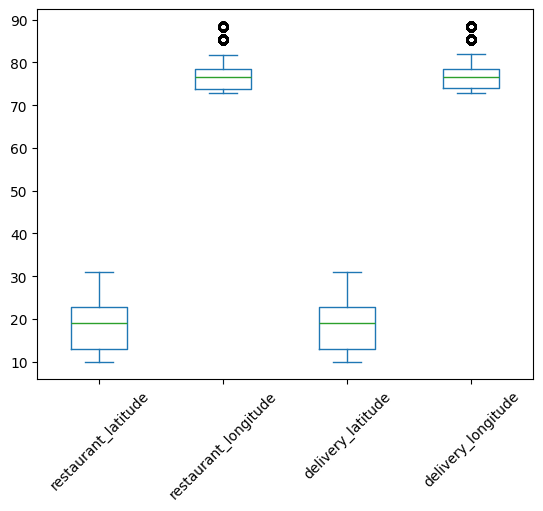

In [94]:
df[location_columns].plot(kind="box")

plt.xticks(rotation=45)

display(df[location_columns].describe())

In [95]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

for col in cat_cols:
    print(f"For {col} unique values are: {df[col].unique()}",end="\n\n")

For rider_id unique values are: <ArrowStringArray>
[  'INDORES13DEL02 ',   'BANGRES18DEL02 ',   'BANGRES19DEL01 ',
  'COIMBRES13DEL02 ',   'CHENRES12DEL01 ',    'HYDRES09DEL03 ',
 'RANCHIRES15DEL01 ',    'MYSRES15DEL02 ',    'HYDRES05DEL02 ',
    'DEHRES17DEL01 ',
 ...
    'KNPRES18DEL01 ',    'BHPRES08DEL03 ',   'AURGRES13DEL01 ',
   'LUDHRES03DEL02 ',    'KNPRES05DEL01 ',    'GOARES01DEL03 ',
    'KOCRES08DEL03 ',    'KOCRES04DEL01 ',    'BHPRES06DEL03 ',
    'GOARES03DEL03 ']
Length: 1320, dtype: str

For weather unique values are: <ArrowStringArray>
['sunny', 'stormy', 'sandstorms', 'cloudy', 'fog', 'windy', nan]
Length: 7, dtype: str

For traffic unique values are: <ArrowStringArray>
['high', 'jam', 'low', 'medium', nan]
Length: 5, dtype: str

For type_of_order unique values are: <ArrowStringArray>
['snack', 'drinks', 'buffet', 'meal']
Length: 4, dtype: str

For type_of_vehicle unique values are: <ArrowStringArray>
['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
Length: 4

C:\Users\msi 1\AppData\Local\Temp\ipykernel_15872\1339322652.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


<Axes: >

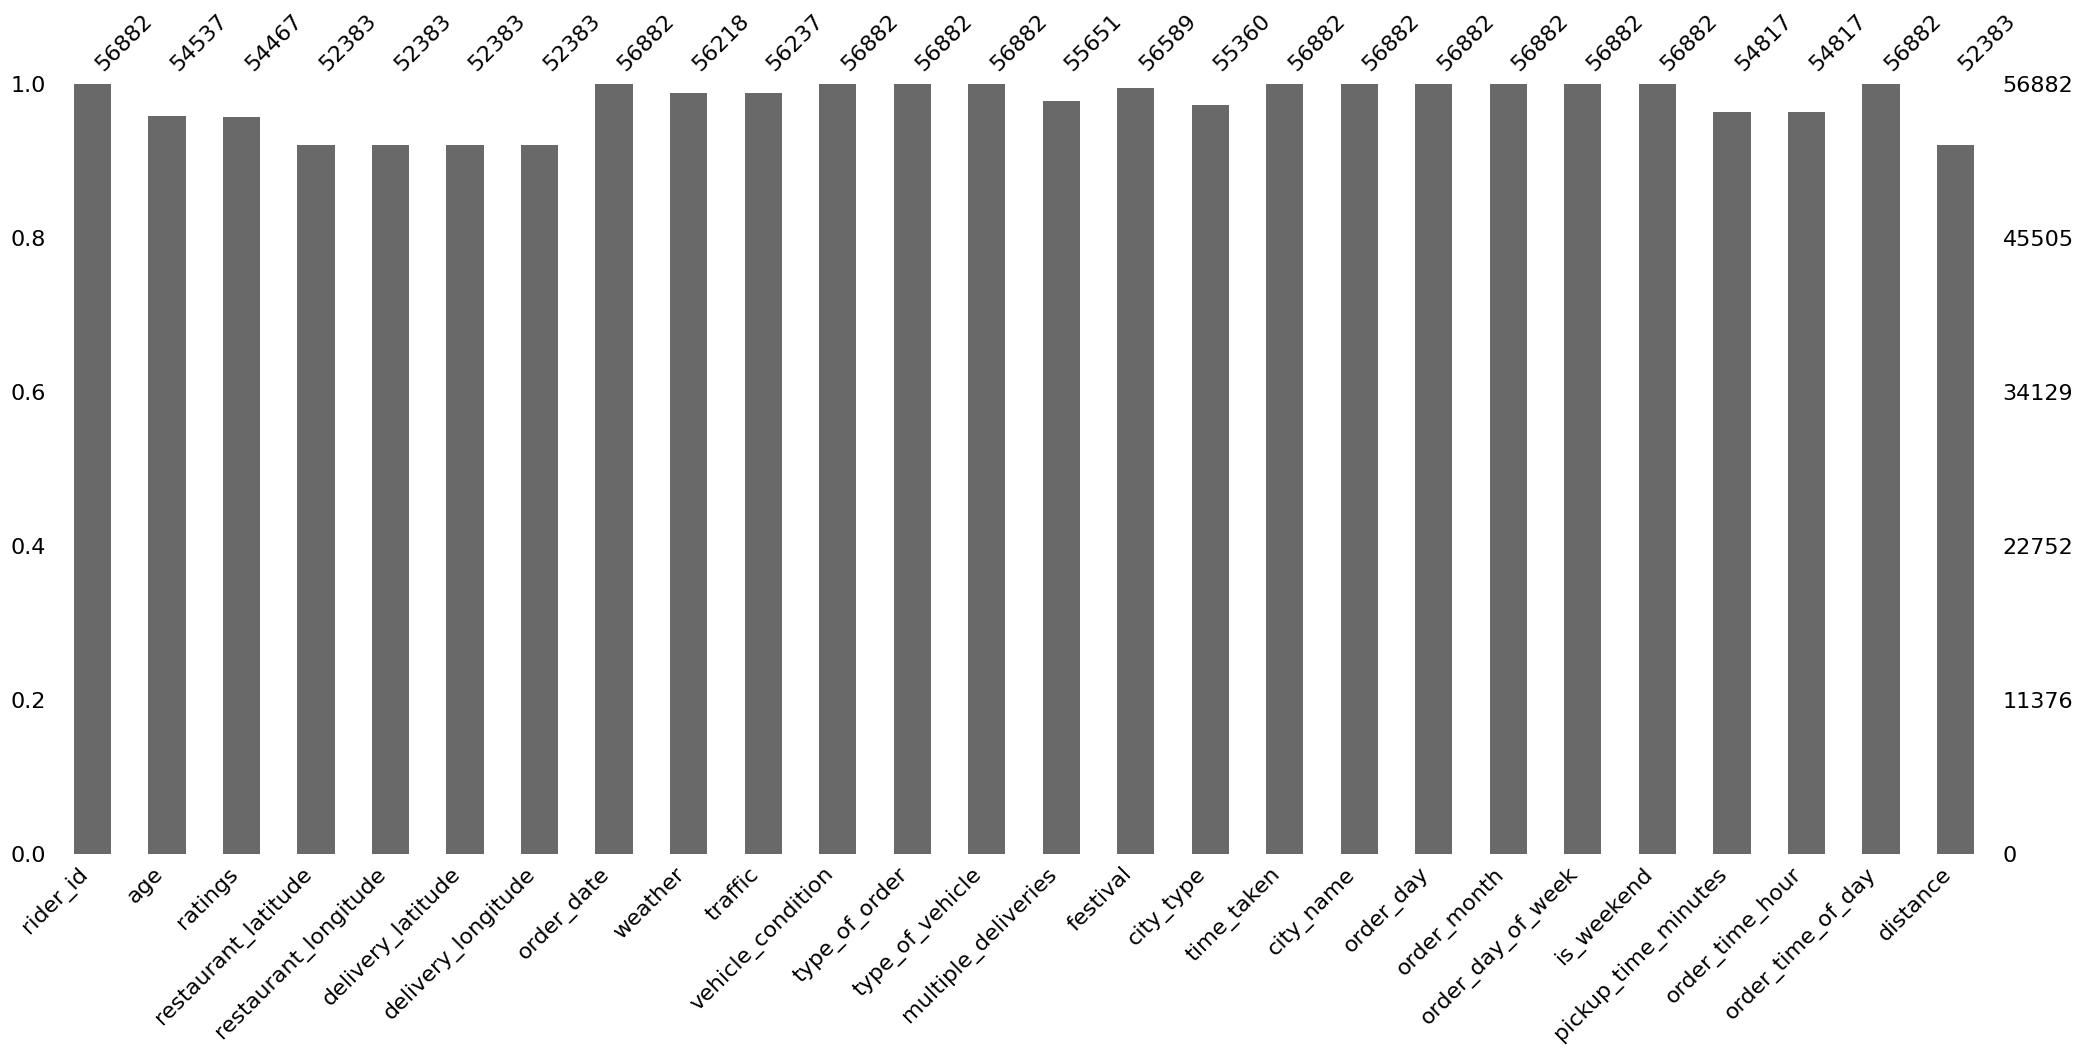

In [96]:
msno.bar(df)

<Axes: >

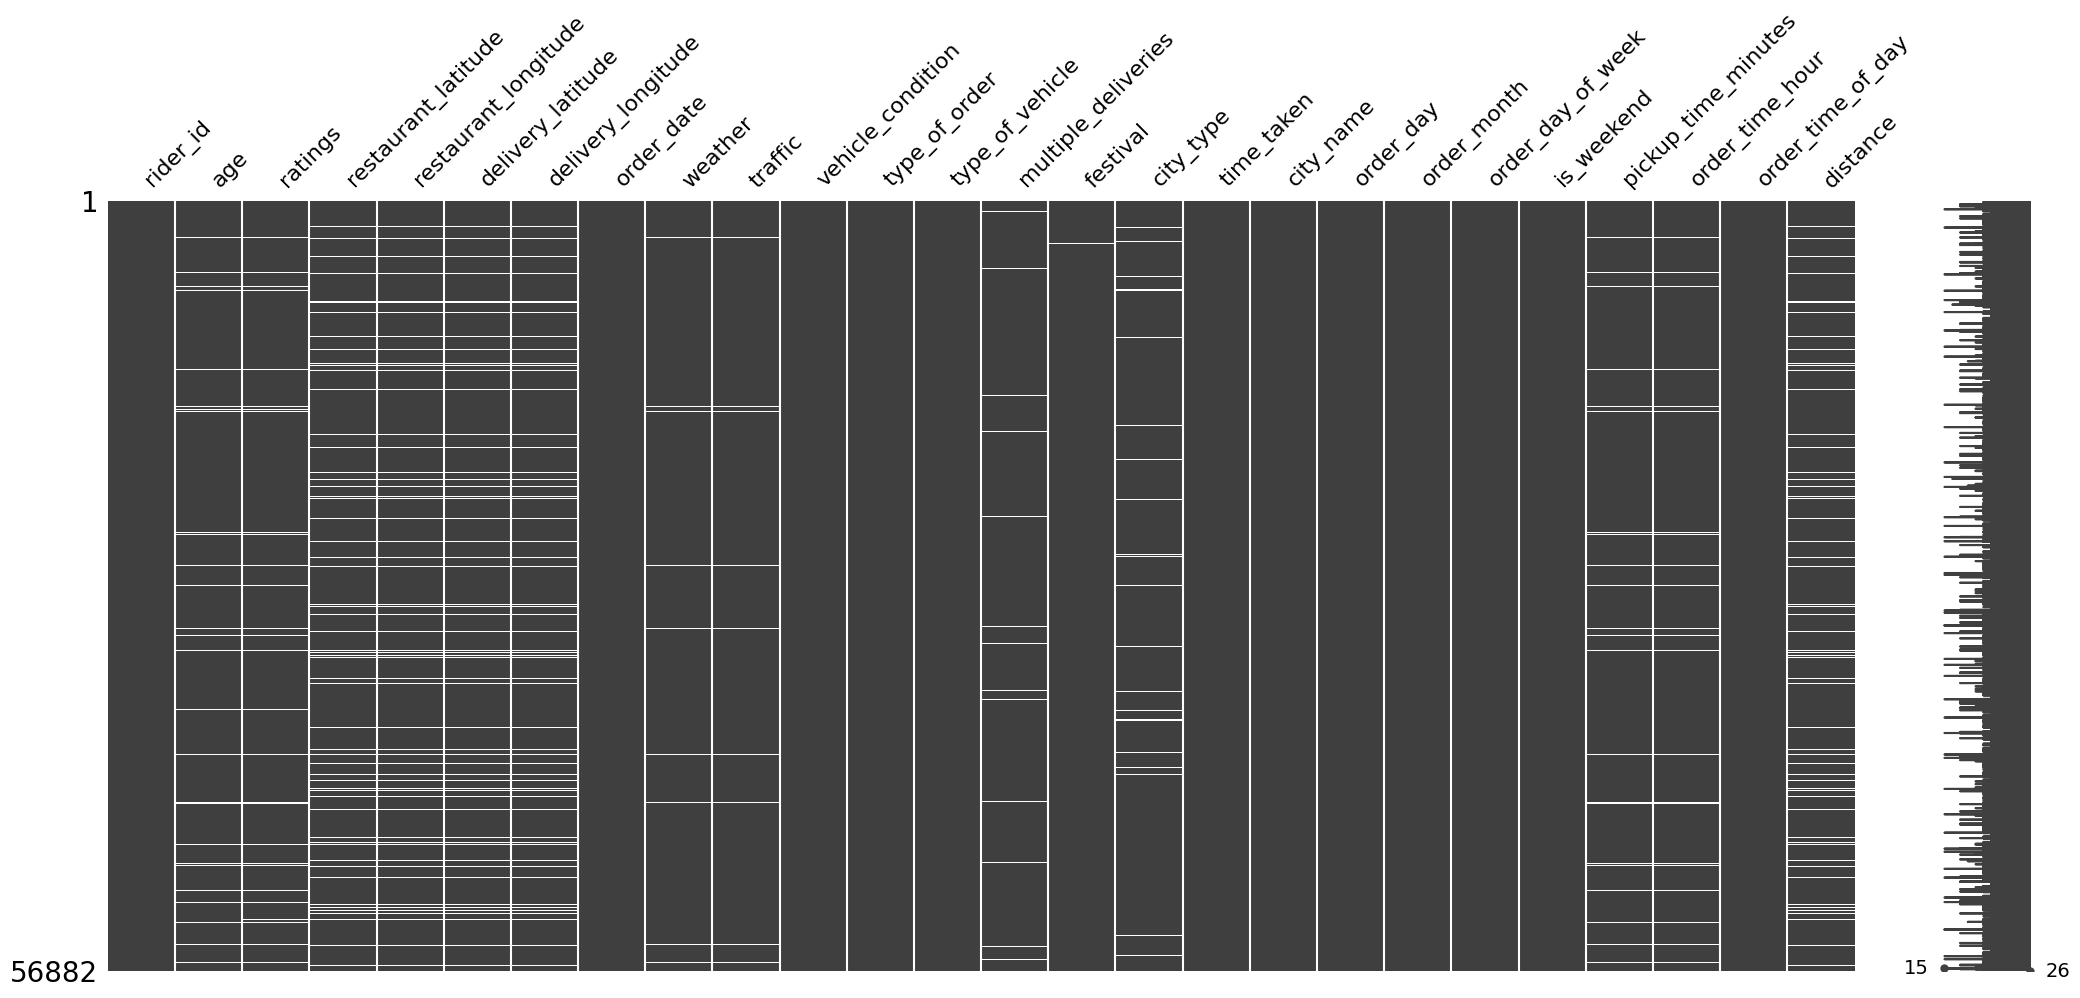

In [97]:
msno.matrix(df)

<Axes: >

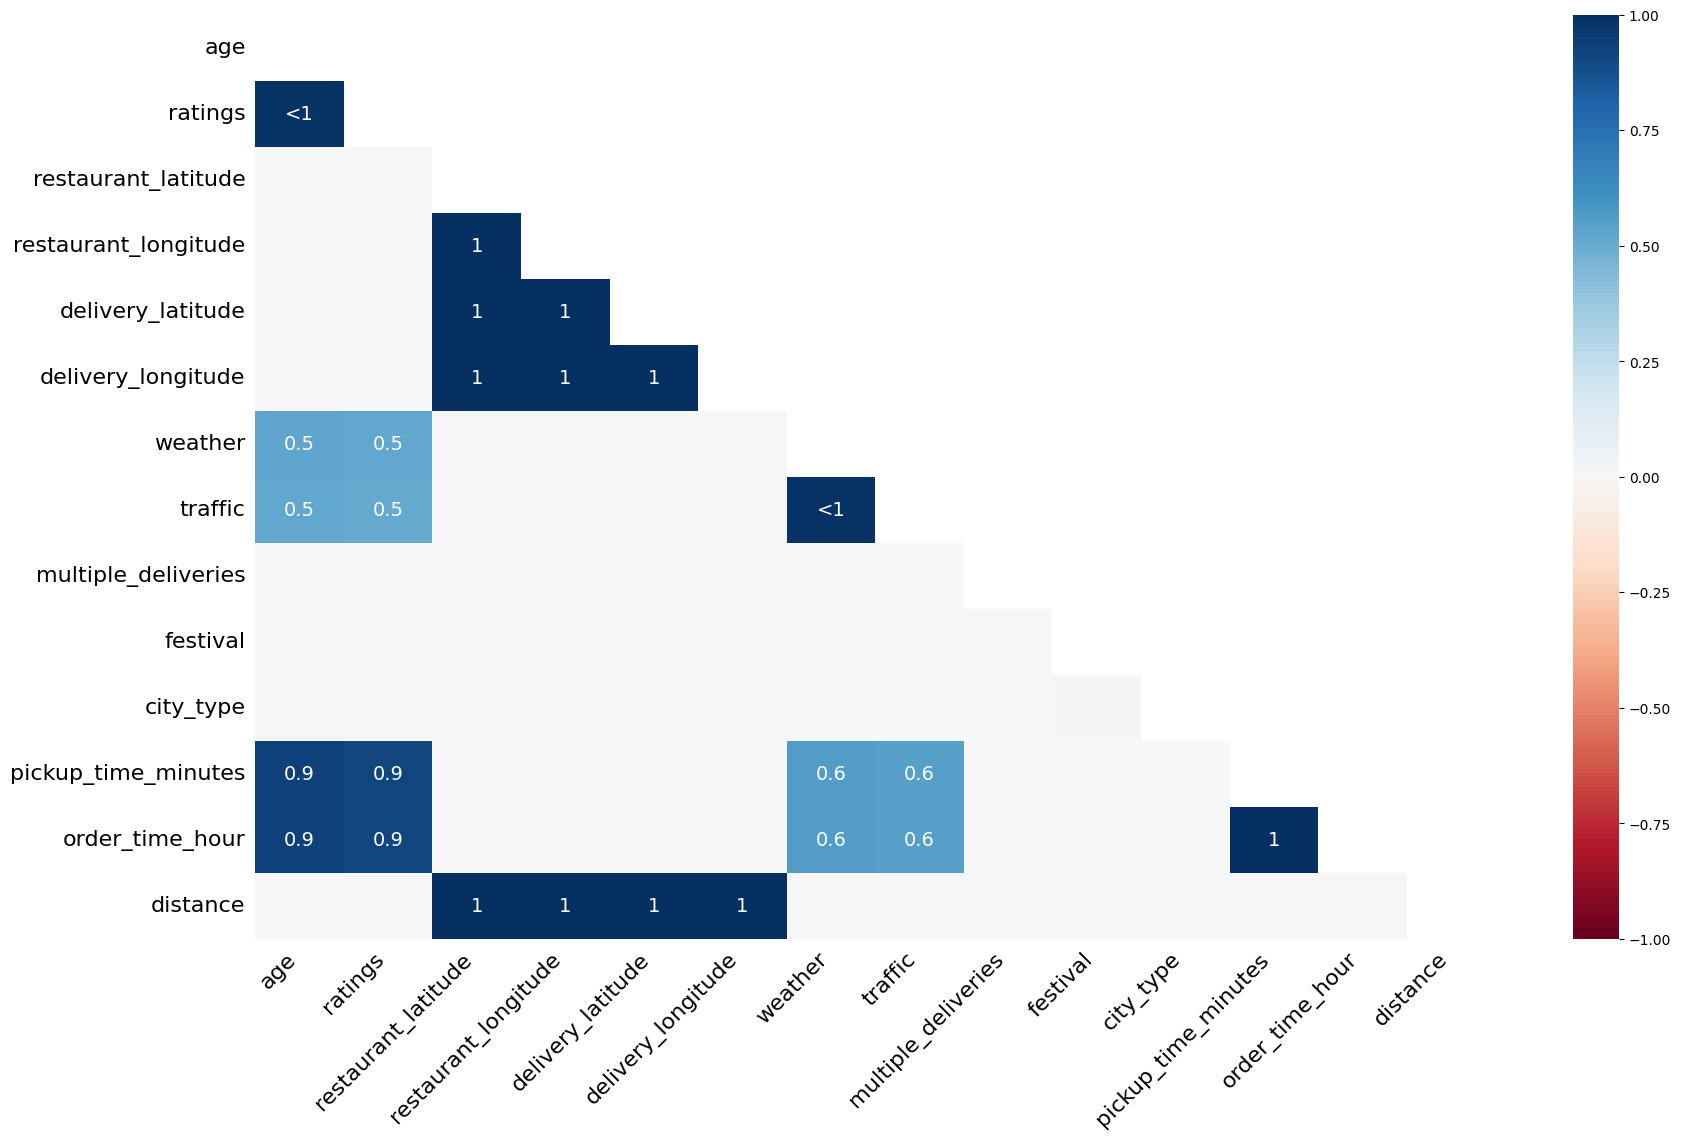

In [98]:
msno.heatmap(df)

In [99]:
df = df.assign(
                        distance_type = pd.cut(df["distance"],bins=[0,5,10,15,25],
                                               right=False,labels=["short","medium","long","very_long"]))

In [100]:
df.to_csv(r"D:\vs code projects\swiggy_delivery_time\data\raw\final_data.csv",index=False)